In [6]:
from datasets import load_dataset

In [7]:
ds = load_dataset("naver-clova-ix/cord-v2")

In [8]:
train = ds["train"]
train

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 800
})

In [10]:
sample = train[0]

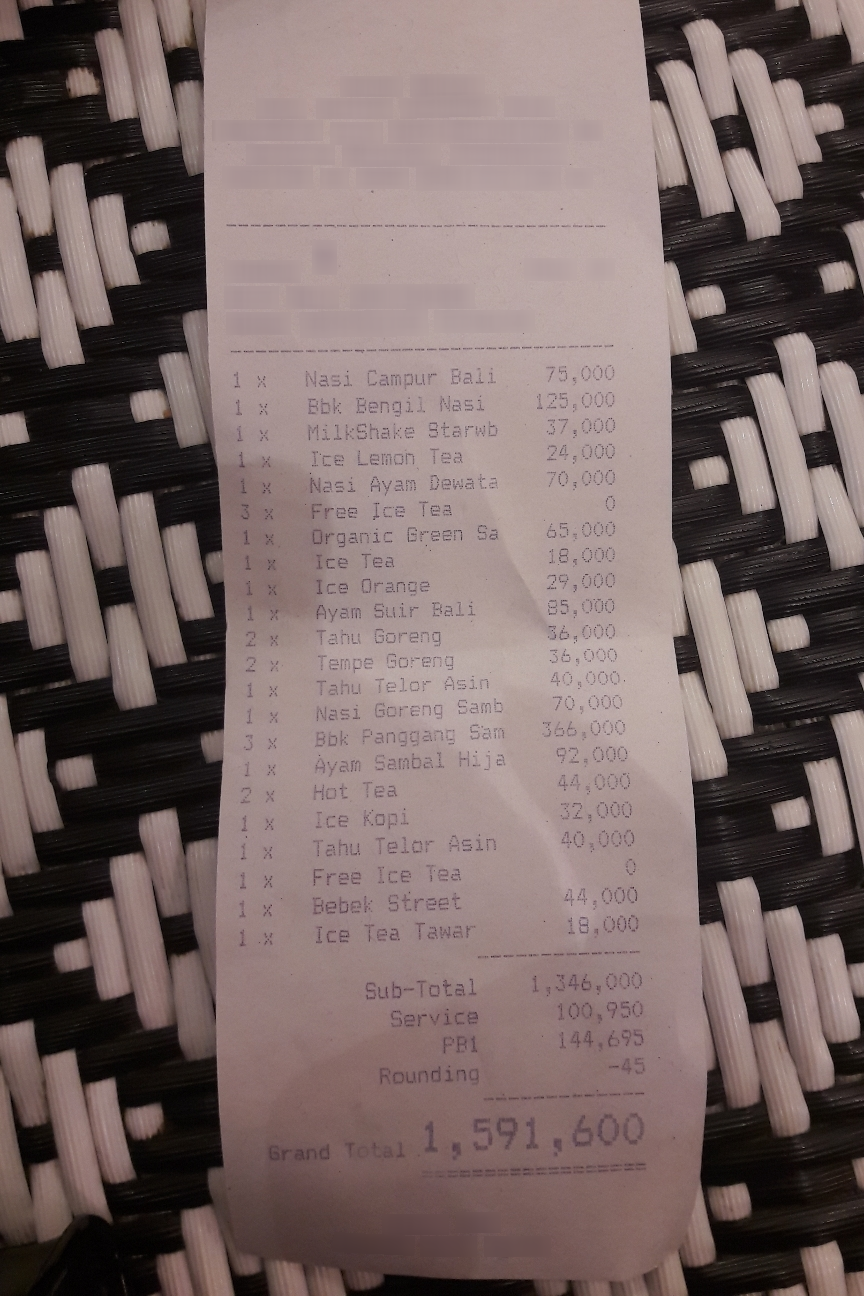

In [11]:
from PIL import Image
import numpy as np
# sample image
img = Image.fromarray(np.array(sample["image"]))
img

In [12]:
# sample ground truth
gt = sample['ground_truth']
# read it as json
import json
gt = json.loads(gt)
gt.keys()


dict_keys(['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare'])

In [13]:
gt['meta']

{'version': '2.0.0',
 'split': 'train',
 'image_id': 0,
 'image_size': {'width': 864, 'height': 1296}}

In [14]:
gt['roi']

{}

In [15]:
gt['repeating_symbol']

[]

In [16]:
gt['valid_line']

[{'words': [{'quad': {'x2': 244,
     'y3': 390,
     'x3': 244,
     'y4': 390,
     'x1': 232,
     'y1': 372,
     'x4': 232,
     'y2': 372},
    'is_key': 0,
    'row_id': 2179893,
    'text': '1'},
   {'quad': {'x2': 270,
     'y3': 390,
     'x3': 270,
     'y4': 390,
     'x1': 256,
     'y1': 374,
     'x4': 256,
     'y2': 374},
    'is_key': 0,
    'row_id': 2179893,
    'text': 'x'}],
  'category': 'menu.cnt',
  'group_id': 3,
  'sub_group_id': 0},
 {'words': [{'quad': {'x2': 354,
     'y3': 390,
     'x3': 354,
     'y4': 390,
     'x1': 302,
     'y1': 368,
     'x4': 302,
     'y2': 368},
    'is_key': 0,
    'row_id': 2179893,
    'text': 'Nasi'},
   {'quad': {'x2': 440,
     'y3': 391,
     'x3': 439,
     'y4': 388,
     'x1': 364,
     'y1': 365,
     'x4': 363,
     'y2': 368},
    'is_key': 0,
    'row_id': 2179893,
    'text': 'Campur'},
   {'quad': {'x2': 497,
     'y3': 385,
     'x3': 499,
     'y4': 388,
     'x1': 446,
     'y1': 365,
     'x4': 448,
     'y2

In [17]:
# count of annotations
count = 0
for line in gt['valid_line']:
    count += len(line['words'])
count

135

In [18]:
import random
labels = [
    "menu.nm", "menu.num", "menu.unitprice", "menu.cnt", "menu.discountprice", "menu.price",
    "menu.itemsubtotal", "menu.vatyn", "menu.etc", "menu.sub_nm", "menu.sub_num", "menu.sub_unitprice",
    "menu.sub_cnt", "menu.sub_discountprice", "menu.sub_price", "menu.sub_etc", "void_menu.nm",
    "voidmenu.num", "voidmenu.unitprice", "voidmenu.cnt", "void_menu.price", "voidmenu.etc",
    "sub_total.subtotal_price", "sub_total.discount_price", "sub_total.subtotal_count", "sub_total.service_price",
    "sub_total.othersvc_price", "sub_total.tax_price", "sub_total.tax_and_service", "sub_total.etc",
    "voidtotal.subtotal_price", "voidtotal.tax_price", "voidtotal.total_price", "voidtotal.etc",
    "total.total_price", "total.total_etc", "total.cashprice", "total.changeprice", "total.creditcardprice",
    "total.emoneyprice", "total.menutype_cnt", "total.menuqty_cnt"
]

get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
colors = get_colors(len(labels))
print(colors)

['#aa3dc1', '#0718a3', '#8987f5', '#3c326c', '#06c13c', '#7fd031', '#916c24', '#548983', '#fbcb1a', '#431188', '#977ff2', '#0cf712', '#d726fc', '#d63625', '#495267', '#9f4a64', '#24dbd2', '#876453', '#7d9975', '#8d0a7a', '#9302ea', '#c21cc0', '#9cf3e0', '#8c2302', '#420ee8', '#cc65c8', '#4d1d2c', '#f1830c', '#ac350e', '#cf8675', '#dbe9b9', '#a80888', '#bd7625', '#de02fb', '#a0640d', '#f489f9', '#52f8bf', '#8fec0c', '#23f1e9', '#91d1e0', '#d30f2f', '#b62254']


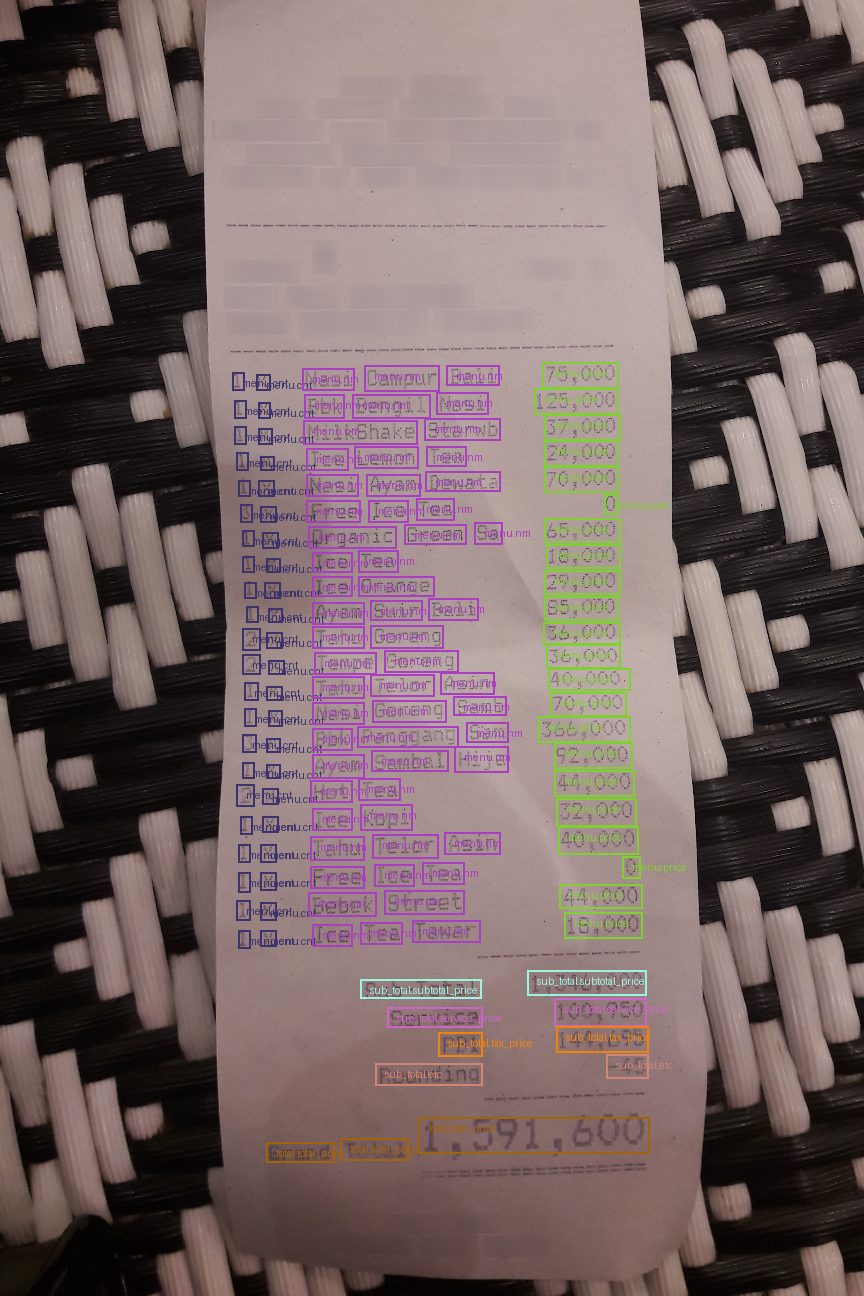

In [19]:
from PIL import ImageDraw, ImageFont, Image
import numpy as np

img = Image.fromarray(np.array(sample["image"]))

draw = ImageDraw.Draw(img, "RGBA")

font = ImageFont.load_default()

label2color = {label: colors[idx] for idx, label in enumerate(labels)}

for annotation in gt['valid_line']:
  label = annotation['category']
  words = annotation['words']
  for word in words:
    coordinates = word['quad']
    x1, y1 = coordinates['x1'], coordinates['y1']
    x3, y3 = coordinates['x3'], coordinates['y3']
    box = [x1, y1, x3, y3]
    draw.rectangle(box, outline=label2color[label], width=2)
    draw.text((box[0]+10, box[1]+5), label, fill=label2color[label], font=font)

img

In [ ]:
# store the dataset locally
ds.save_to_disk("cord-v2")

Saving the dataset (0/4 shards):   0%|          | 0/800 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]